# Insurance Claims — Data Preparation

**Three modelling targets:**
1. Claim Frequency — `claim_count`
2. Claim Severity — `claim_amount`
3. Pure Premium — `pure_premium = total_claim_amount / earned_exposure`

## 1. Imports

In [1]:

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
get_ipython().run_line_magic('matplotlib', 'inline')


## 2. Load Data

In [2]:

raw       = pd.read_excel(r"C:\Users\DorothyCheruiyot\Desktop\Projects\insurance_claims\data\insurance_data_features.xlsx", sheet_name=None)
customers = raw['Customers'].copy()
policies  = raw['Policies'].copy()
claims    = raw['Claims'].copy()

# Standardise column names
def snake(df):
    df.columns = (df.columns.str.strip().str.lower()
                  .str.replace(r'[^a-z0-9]+', '_', regex=True).str.strip('_'))
    return df

customers, policies, claims = snake(customers), snake(policies), snake(claims)

for name, df in [('Customers', customers), ('Policies', policies), ('Claims', claims)]:
    print(f"{name:10s}: {df.shape[0]:,} rows x {df.shape[1]} cols")


Customers : 10,000 rows x 12 cols
Policies  : 18,000 rows x 11 cols
Claims    : 5,000 rows x 11 cols


## 3. Merge

In [3]:

# claims -> policies -> customers
df = (claims
      .merge(policies, on='policy_id', how='left', suffixes=('', '_pol'))
      .merge(customers, on='customer_id', how='left', suffixes=('', '_cust')))

print(f"Merged shape: {df.shape}")
print(f"Columns: {list(df.columns)}")


Merged shape: (5000, 32)
Columns: ['claim_id', 'policy_id', 'customer_id', 'claim_date', 'claim_type', 'claim_amount', 'claim_status', 'settlement_days', 'settlement_date', 'fraud_flag', 'coverage_type', 'customer_id_pol', 'coverage_type_pol', 'start_date', 'end_date', 'annual_premium', 'excess_amount', 'sum_insured', 'policy_status', 'renewal_count', 'distribution_channel', 'age', 'gender', 'region', 'income_band', 'tenure_years', 'credit_score', 'payment_pattern', 'late_payments_12m', 'prior_claims_count', 'occupation', 'postcode_district']


## 4. Data Quality

In [4]:

print("--- Shape ---")
print(df.shape)

print("\n--- Dtypes ---")
print(df.dtypes.to_string())

print("\n--- Missing values ---")
miss = df.isnull().sum()
print(miss[miss > 0] if miss.any() else "None")

print("\n--- Duplicates ---")
print(f"Duplicate claim_id: {df['claim_id'].duplicated().sum()}")


--- Shape ---
(5000, 32)

--- Dtypes ---
claim_id                           str
policy_id                          str
customer_id                        str
claim_date              datetime64[us]
claim_type                         str
claim_amount                   float64
claim_status                       str
settlement_days                  int64
settlement_date         datetime64[us]
fraud_flag                       int64
coverage_type                      str
customer_id_pol                    str
coverage_type_pol                  str
start_date              datetime64[us]
end_date                datetime64[us]
annual_premium                 float64
excess_amount                    int64
sum_insured                      int64
policy_status                      str
renewal_count                    int64
distribution_channel               str
age                              int64
gender                             str
region                             str
income_band            

In [5]:

print("--- Numeric summary ---")
display(df.describe().T)


--- Numeric summary ---


,count,mean,min,25%,50%,75%,max,std
claim_date,5000,2023-04-09 00:21:18.720000,2021-01-13 00:00:00,2022-05-28 18:00:00,2023-05-02 00:00:00,2024-02-29 00:00:00,2024-12-31 00:00:00,NaN
claim_amount,5000.00,10947.55,278.79,3105.91,6410.15,14720.15,75000.00,11480.45
settlement_days,5000.00,93.10,7.00,49.00,93.00,137.00,180.00,50.29
settlement_date,5000,2023-07-11 02:44:26.880000,2021-01-23 00:00:00,2022-08-30 00:00:00,2023-07-29 00:00:00,2024-05-31 00:00:00,2025-06-13 00:00:00,NaN
fraud_flag,5000.00,0.04,0.00,0.00,0.00,0.00,1.00,0.19
start_date,5000,2022-10-02 18:42:54.720000,2021-01-01 00:00:00,2021-11-18 00:00:00,2022-09-29 00:00:00,2023-08-22 00:00:00,2024-07-04 00:00:00,NaN
end_date,5000,2023-11-15 22:40:30.720000,2021-07-01 00:00:00,2023-01-05 18:00:00,2023-11-21 12:00:00,2024-09-21 06:00:00,2026-07-04 00:00:00,NaN
annual_premium,5000.00,1127.90,80.04,431.04,783.82,1358.14,4999.68,1041.97
excess_amount,5000.00,250.18,100.00,150.00,200.00,300.00,500.00,129.08
sum_insured,5000.00,73056.48,2800.00,26000.00,49000.00,90325.00,484200.00,73788.47


In [6]:

print("--- Categorical summary ---")
display(df.describe(include='object').T)


--- Categorical summary ---


,count,unique,top,freq
claim_id,5000,5000,CLM0000001,1
policy_id,5000,4334,POL009396,4
customer_id,5000,3527,CUST05581,7
claim_type,5000,7,Medical,1522
claim_status,5000,3,Settled,2976
coverage_type,5000,6,Motor,874
customer_id_pol,5000,3527,CUST05581,7
coverage_type_pol,5000,6,Motor,874
policy_status,5000,2,Active,4411
distribution_channel,5000,4,Broker,1300


## 5. EDA

### 5.1 Claim Amount Distribution

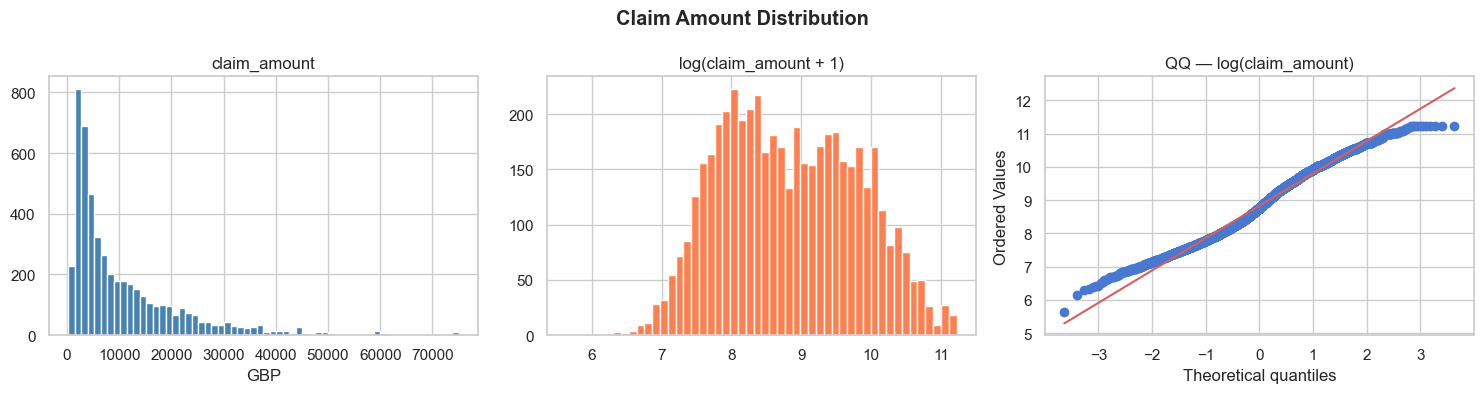

count    5000.00
mean    10947.55
std     11480.45
min       278.79
25%      3105.91
50%      6410.15
75%     14720.15
max     75000.00
Name: claim_amount, dtype: float64
Skewness: 2.11


In [7]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['claim_amount'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('claim_amount'); axes[0].set_xlabel('GBP')

axes[1].hist(np.log1p(df['claim_amount']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('log(claim_amount + 1)')

stats.probplot(np.log1p(df['claim_amount']), dist='norm', plot=axes[2])
axes[2].set_title('QQ — log(claim_amount)')

plt.suptitle('Claim Amount Distribution', fontweight='bold')
plt.tight_layout(); plt.show()

print(df['claim_amount'].describe())
print(f"Skewness: {df['claim_amount'].skew():.2f}")


### 5.2 Claim Amount by Coverage Type & Claim Type

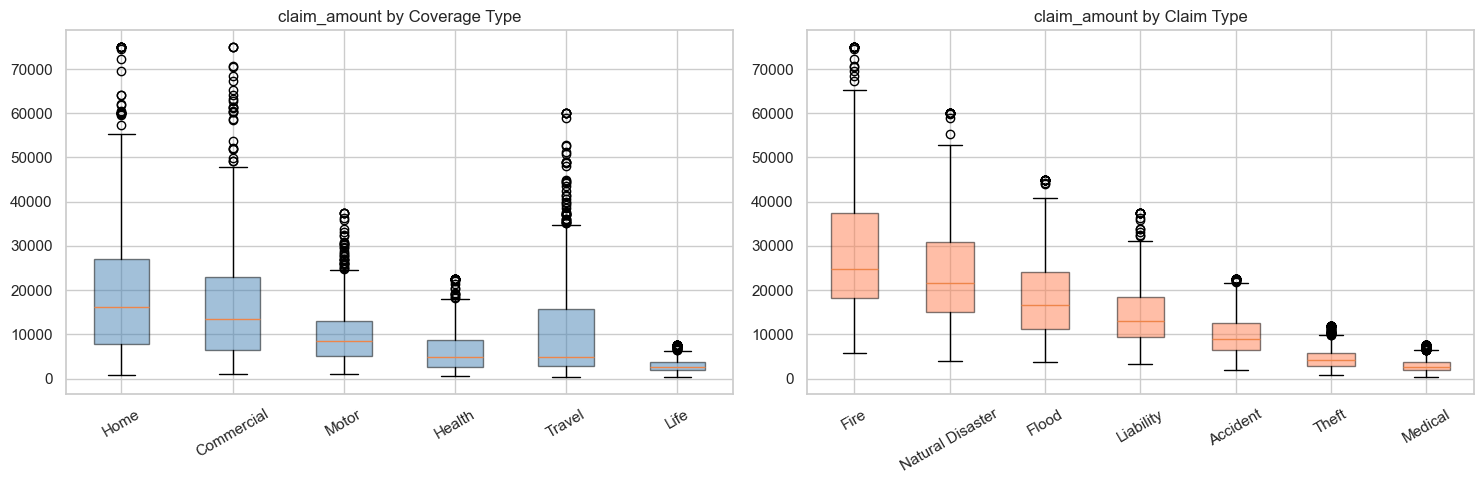

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cov_order = df.groupby('coverage_type')['claim_amount'].median().sort_values(ascending=False).index.tolist()
data_cov = [df[df['coverage_type'] == c]['claim_amount'].values for c in cov_order]
bp1 = axes[0].boxplot(data_cov, patch_artist=True, labels=cov_order)
for patch in bp1['boxes']: patch.set(facecolor='steelblue', alpha=0.5)
axes[0].set_title('claim_amount by Coverage Type')
axes[0].tick_params(axis='x', rotation=30)

cl_order = df.groupby('claim_type')['claim_amount'].median().sort_values(ascending=False).index.tolist()
data_cl = [df[df['claim_type'] == c]['claim_amount'].values for c in cl_order]
bp2 = axes[1].boxplot(data_cl, patch_artist=True, labels=cl_order)
for patch in bp2['boxes']: patch.set(facecolor='coral', alpha=0.5)
axes[1].set_title('claim_amount by Claim Type')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()


### 5.3 Key Categorical Features

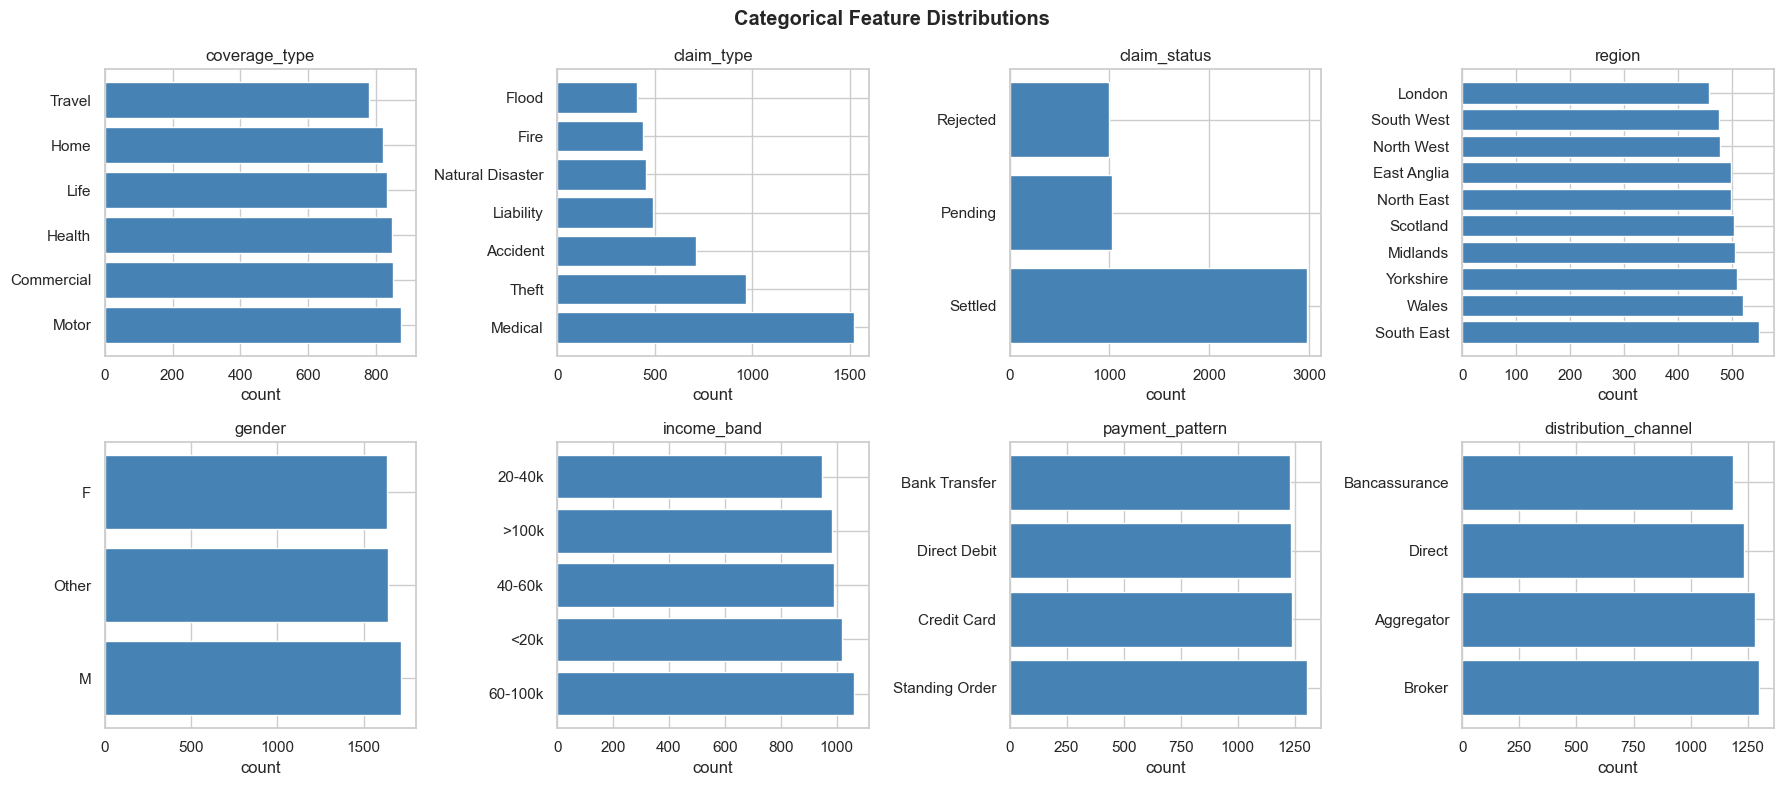

In [9]:

cat_cols = ['coverage_type', 'claim_type', 'claim_status', 'region',
            'gender', 'income_band', 'payment_pattern', 'distribution_channel']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].barh(counts.index, counts.values, color='steelblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('count')

plt.suptitle('Categorical Feature Distributions', fontweight='bold')
plt.tight_layout(); plt.show()


### 5.4 Key Numeric Features

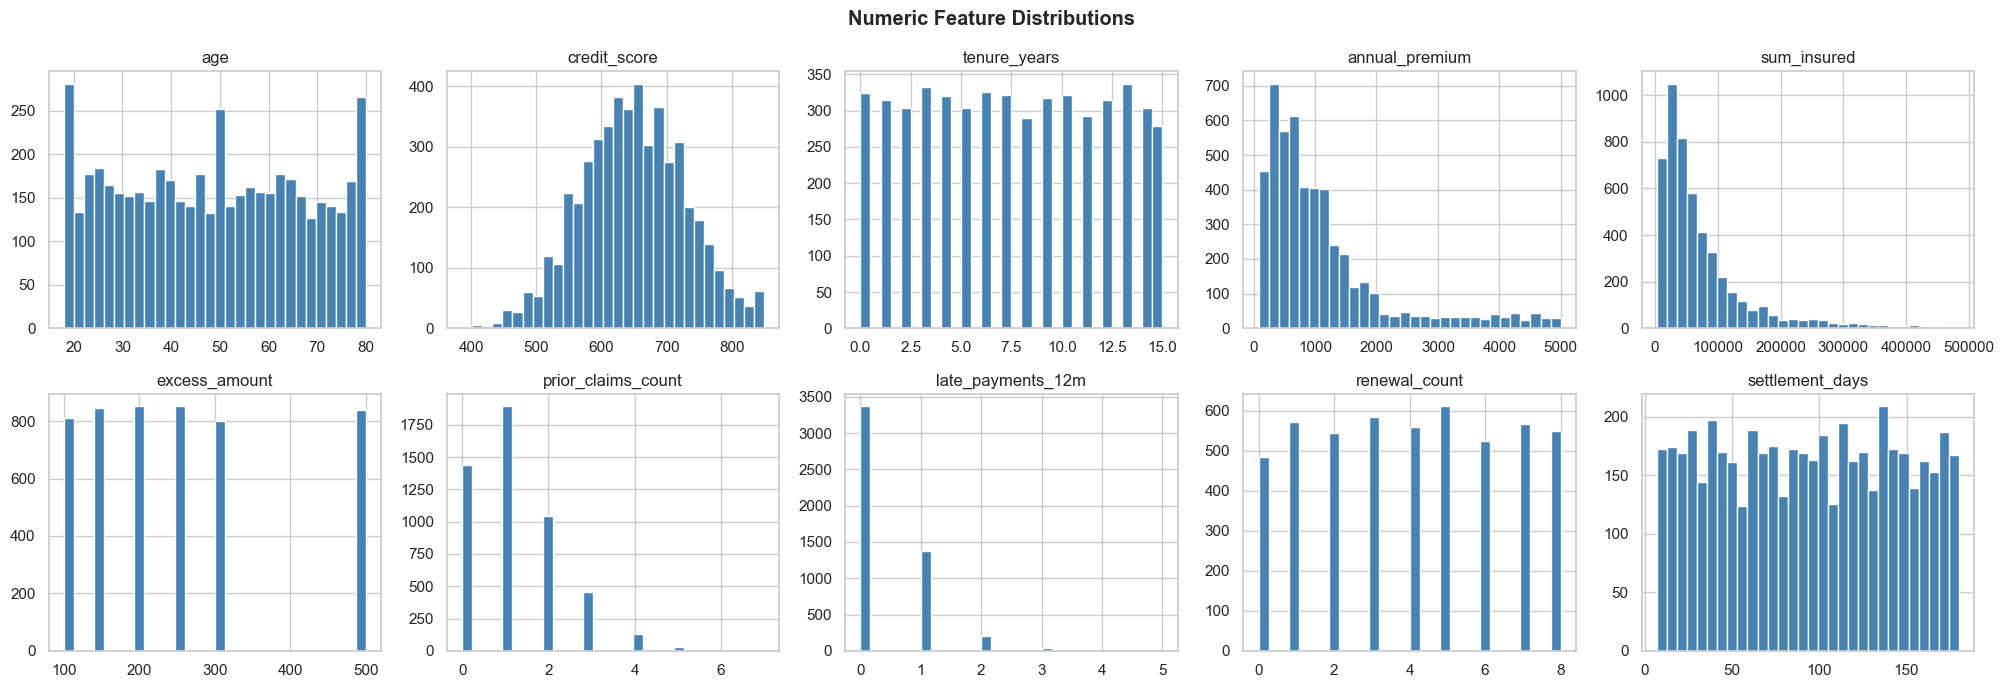

In [10]:

num_cols = ['age', 'credit_score', 'tenure_years', 'annual_premium',
            'sum_insured', 'excess_amount', 'prior_claims_count',
            'late_payments_12m', 'renewal_count', 'settlement_days']

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)

plt.suptitle('Numeric Feature Distributions', fontweight='bold')
plt.tight_layout(); plt.show()


### 5.5 Claim Volume Over Time

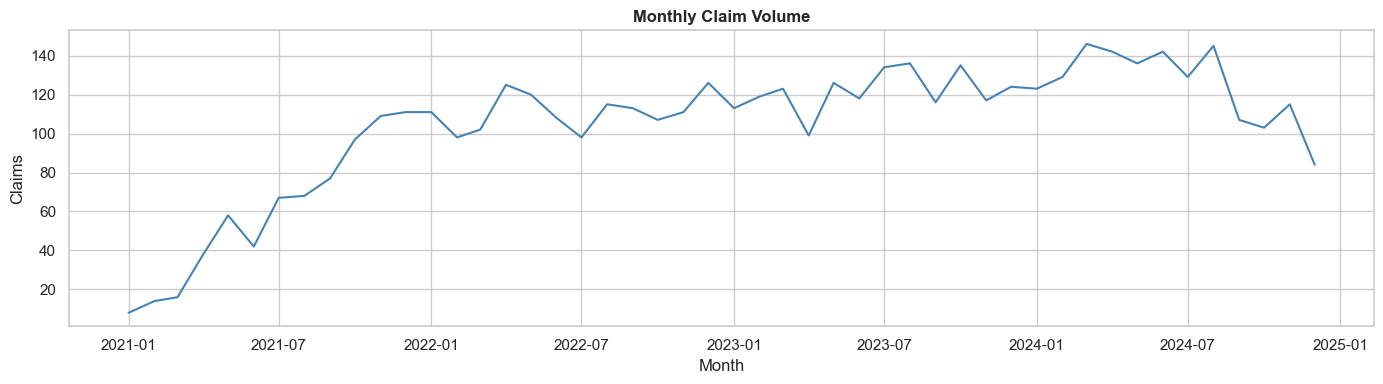

In [11]:

df['claim_month'] = df['claim_date'].dt.to_period('M')
monthly = df.groupby('claim_month').size().reset_index(name='claim_count')
monthly['claim_month_dt'] = monthly['claim_month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly['claim_month_dt'], monthly['claim_count'], color='steelblue', linewidth=1.5)
ax.set_title('Monthly Claim Volume', fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Claims')
plt.tight_layout(); plt.show()


### 5.6 Fraud Flag

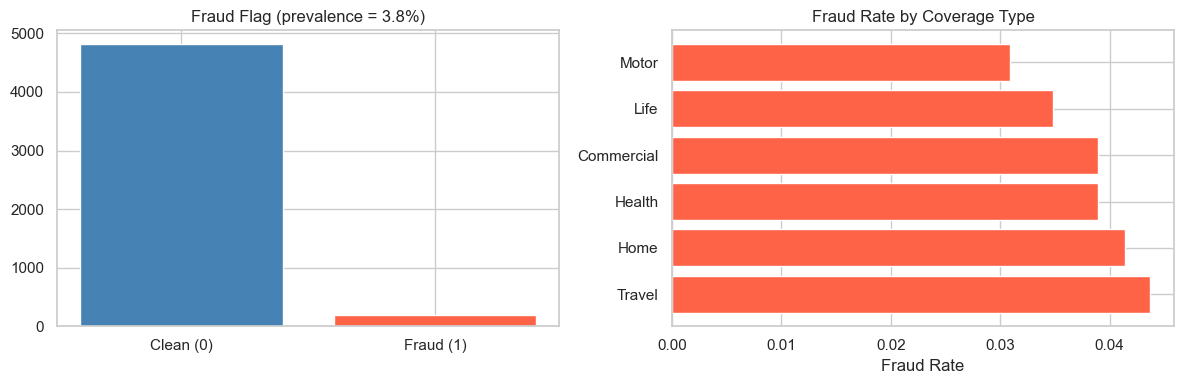

In [12]:

fraud_rate = df['fraud_flag'].mean()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Clean (0)', 'Fraud (1)'], df['fraud_flag'].value_counts().sort_index().values,
            color=['steelblue', 'tomato'])
axes[0].set_title(f'Fraud Flag (prevalence = {fraud_rate:.1%})')

# Fraud rate by coverage type
fraud_by_cov = df.groupby('coverage_type')['fraud_flag'].mean().sort_values(ascending=False)
axes[1].barh(fraud_by_cov.index, fraud_by_cov.values, color='tomato')
axes[1].set_title('Fraud Rate by Coverage Type')
axes[1].set_xlabel('Fraud Rate')

plt.tight_layout(); plt.show()


### 5.7 Correlation — Numeric Features vs Claim Amount

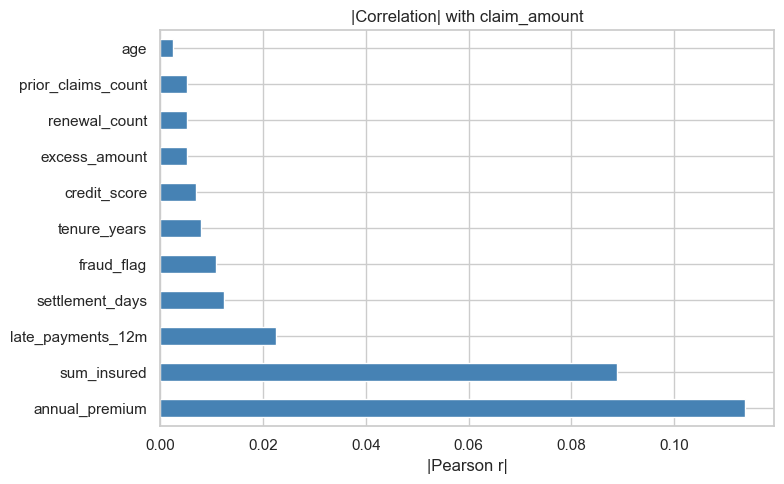

In [13]:

num_feats = df.select_dtypes(include=[np.number]).columns.drop('claim_amount', errors='ignore')
corr = df[num_feats].corrwith(df['claim_amount']).abs().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 5))
corr.plot.barh(ax=ax, color='steelblue')
ax.set_title('|Correlation| with claim_amount')
ax.set_xlabel('|Pearson r|')
plt.tight_layout(); plt.show()


## 6. Build Target Datasets

### 6.1 Claim Frequency

In [14]:
df.head()

,claim_id,policy_id,customer_id,claim_date,claim_type,claim_amount,claim_status,settlement_days,settlement_date,fraud_flag,coverage_type,customer_id_pol,coverage_type_pol,start_date,end_date,annual_premium,excess_amount,sum_insured,policy_status,renewal_count,distribution_channel,age,gender,region,income_band,tenure_years,credit_score,payment_pattern,late_payments_12m,prior_claims_count,occupation,postcode_district,claim_month
0,CLM0000001,POL001589,CUST04742,2021-02-28,Accident,3070.31,Settled,118,2021-06-26,0,Health,CUST04742,Health,2021-01-06,2022-01-06,1397.46,500,117700,Lapsed,5,Bancassurance,45,F,East Anglia,>100k,6,720,Direct Debit,0,1,Diplomatic Services operational officer,ST7R,2021-02
1,CLM0000002,POL010598,CUST09209,2024-07-18,Medical,2668.14,Settled,83,2024-10-09,0,Life,CUST09209,Life,2024-02-01,2024-07-30,807.95,250,64100,Active,5,Bancassurance,52,Other,Yorkshire,20-40k,11,692,Standing Order,0,1,Data scientist,CW4N,2024-07
2,CLM0000003,POL002080,CUST01646,2022-11-16,Accident,19384.22,Settled,116,2023-03-12,0,Motor,CUST01646,Motor,2022-08-02,2023-01-29,962.36,500,76900,Active,3,Broker,65,M,London,60-100k,3,618,Credit Card,0,2,Logistics and distribution manager,HR3,2022-11
3,CLM0000004,POL006528,CUST09866,2021-06-13,Theft,3965.53,Settled,13,2021-06-26,0,Motor,CUST09866,Motor,2021-05-21,2022-05-21,407.76,250,14800,Active,4,Broker,32,M,North West,<20k,8,561,Credit Card,1,0,"Programme researcher, broadcasting/film/video",W9 3,2021-06
4,CLM0000005,POL006798,CUST07857,2024-10-27,Medical,2170.25,Pending,139,2025-03-15,0,Travel,CUST07857,Travel,2024-05-02,2025-05-02,362.66,250,24500,Active,3,Bancassurance,62,M,East Anglia,>100k,4,827,Bank Transfer,0,0,Quarry manager,M11,2024-10


In [15]:
# Add year_month period column before grouping
df['year_month'] = df['claim_date'].dt.to_period('M')

# All claims (all statuses) - frequency is about occurrence, not outcome
df_freq = (df.groupby(['coverage_type', 'region', 'year_month'])
             .size()
             .reset_index(name='claim_count'))

print(f"Shape: {df_freq.shape}")
print()
print(df_freq['claim_count'].describe())

df_freq.head()


Shape: (2258, 4)

count   2258.00
mean       2.21
std        1.30
min        1.00
25%        1.00
50%        2.00
75%        3.00
max        9.00
Name: claim_count, dtype: float64


,coverage_type,region,year_month,claim_count
0,Commercial,East Anglia,2021-02,1
1,Commercial,East Anglia,2021-04,2
2,Commercial,East Anglia,2021-07,1
3,Commercial,East Anglia,2021-09,3
4,Commercial,East Anglia,2021-10,3


### 6.2 Claim Severity

In [16]:

# Settled claims only — only these have a confirmed final amount
df_sev = df[df['claim_status'] == 'Settled'].copy()

print(f"Shape: {df_sev.shape}")
print(f"({df['claim_status'].value_counts(normalize=True).mul(100).round(1).to_dict()})")
print()
print(df_sev['claim_amount'].describe())
print(f"Skewness: {df_sev['claim_amount'].skew():.2f}")


Shape: (2976, 34)
({'Settled': 59.5, 'Pending': 20.5, 'Rejected': 20.0})

count    2976.00
mean    11071.56
std     11830.28
min       278.79
25%      3148.27
50%      6261.97
75%     14897.36
max     75000.00
Name: claim_amount, dtype: float64
Skewness: 2.16


### 6.3 Pure Premium

In [17]:

# Policy-level: total settled loss / earned exposure
# Earned exposure = policy duration in years
policies['policy_duration_days'] = (policies['end_date'] - policies['start_date']).dt.days
policies['earned_exposure']      = policies['policy_duration_days'] / 365.25

settled_loss = (df[df['claim_status'] == 'Settled']
                .groupby('policy_id')['claim_amount']
                .sum()
                .reset_index(name='total_claim_amount'))

df_pp = (policies
         .merge(customers, on='customer_id', how='left')
         .merge(settled_loss, on='policy_id', how='left'))

df_pp['total_claim_amount'].fillna(0, inplace=True)
df_pp['pure_premium'] = df_pp['total_claim_amount'] / df_pp['earned_exposure']

print(f"Shape: {df_pp.shape}")
print()
print(df_pp['pure_premium'].describe())
print(f"Zero-claim policies: {(df_pp['total_claim_amount'] == 0).mean():.1%}")


Shape: (18000, 26)

count     2703.00
mean     14134.00
std      18590.87
min        268.07
25%       3241.60
50%       7276.82
75%      16941.91
max     152187.50
Name: pure_premium, dtype: float64
Zero-claim policies: 0.0%


## 7. Output Datasets

In [18]:

print("CLAIM FREQUENCY")
print("-" * 40)
display(df_freq.head(10))

print()
print("CLAIM SEVERITY")
print("-" * 40)
display(df_sev[['claim_id','policy_id','customer_id','coverage_type','claim_type',
                'claim_amount','claim_date','region','age','gender','income_band',
                'credit_score','tenure_years','annual_premium','excess_amount',
                'sum_insured','prior_claims_count','settlement_days']].head(10))

print()
print("PURE PREMIUM")
print("-" * 40)
display(df_pp[['policy_id','customer_id','coverage_type','earned_exposure',
               'total_claim_amount','pure_premium','region','age','gender',
               'income_band','credit_score','tenure_years','annual_premium',
               'excess_amount','sum_insured','prior_claims_count']].head(10))


CLAIM FREQUENCY
----------------------------------------


,coverage_type,region,year_month,claim_count
0,Commercial,East Anglia,2021-02,1
1,Commercial,East Anglia,2021-04,2
2,Commercial,East Anglia,2021-07,1
3,Commercial,East Anglia,2021-09,3
4,Commercial,East Anglia,2021-10,3
5,Commercial,East Anglia,2021-12,5
6,Commercial,East Anglia,2022-01,2
7,Commercial,East Anglia,2022-02,2
8,Commercial,East Anglia,2022-04,4
9,Commercial,East Anglia,2022-05,2



CLAIM SEVERITY
----------------------------------------


,claim_id,policy_id,customer_id,coverage_type,claim_type,claim_amount,claim_date,region,age,gender,income_band,credit_score,tenure_years,annual_premium,excess_amount,sum_insured,prior_claims_count,settlement_days
0,CLM0000001,POL001589,CUST04742,Health,Accident,3070.31,2021-02-28,East Anglia,45,F,>100k,720,6,1397.46,500,117700,1,118
1,CLM0000002,POL010598,CUST09209,Life,Medical,2668.14,2024-07-18,Yorkshire,52,Other,20-40k,692,11,807.95,250,64100,1,83
2,CLM0000003,POL002080,CUST01646,Motor,Accident,19384.22,2022-11-16,London,65,M,60-100k,618,3,962.36,500,76900,2,116
3,CLM0000004,POL006528,CUST09866,Motor,Theft,3965.53,2021-06-13,North West,32,M,<20k,561,8,407.76,250,14800,0,13
7,CLM0000008,POL003086,CUST09637,Life,Medical,3786.58,2023-07-18,South East,32,F,40-60k,756,0,1382.61,500,53000,2,83
8,CLM0000009,POL010343,CUST06359,Motor,Accident,5329.61,2022-02-22,East Anglia,27,M,<20k,693,13,1001.39,200,83200,3,15
9,CLM0000010,POL009093,CUST09038,Life,Medical,2636.79,2023-12-18,Wales,38,M,>100k,475,0,1131.09,250,87800,3,35
10,CLM0000011,POL000509,CUST03417,Life,Medical,3070.16,2024-04-23,Wales,72,M,60-100k,643,14,936.77,250,67400,1,81
11,CLM0000012,POL016071,CUST01666,Health,Accident,5012.31,2022-02-18,Yorkshire,33,F,<20k,558,13,1358.14,500,98600,2,34
13,CLM0000014,POL004302,CUST00909,Health,Accident,5647.21,2021-04-10,South East,63,Other,20-40k,719,11,1639.83,200,92600,1,105



PURE PREMIUM
----------------------------------------


,policy_id,customer_id,coverage_type,earned_exposure,total_claim_amount,pure_premium,region,age,gender,income_band,credit_score,tenure_years,annual_premium,excess_amount,sum_insured,prior_claims_count
0,POL000001,CUST00620,Life,0.49,NaN,NaN,South West,63,F,60-100k,630,3,384.22,500,33300,0
1,POL000002,CUST07477,Travel,0.49,NaN,NaN,Yorkshire,69,Other,<20k,685,15,301.01,100,17400,2
2,POL000003,CUST06172,Travel,2.00,NaN,NaN,Wales,56,M,<20k,594,11,314.82,100,21800,1
3,POL000004,CUST01111,Motor,1.00,NaN,NaN,Scotland,48,F,20-40k,642,4,455.55,200,39300,2
4,POL000005,CUST04868,Life,1.00,NaN,NaN,Scotland,46,Other,60-100k,497,14,1002.14,500,30400,0
5,POL000006,CUST08054,Life,2.00,NaN,NaN,Wales,49,M,60-100k,559,11,1194.10,500,50300,1
6,POL000007,CUST09330,Health,0.49,NaN,NaN,North West,64,M,20-40k,689,9,1334.73,300,85900,0
7,POL000008,CUST04615,Life,1.00,NaN,NaN,Scotland,58,F,<20k,850,6,320.80,250,30500,2
8,POL000009,CUST07814,Travel,0.49,NaN,NaN,London,44,M,<20k,715,10,293.44,500,12900,2
9,POL000010,CUST09148,Home,0.49,NaN,NaN,East Anglia,66,M,20-40k,544,12,367.06,250,30900,1


In [19]:

print("Summary")
print("=" * 50)
rows = [
    ["Claim Frequency", len(df_freq), "claim_count", "All claims"],
    ["Claim Severity",  len(df_sev),  "claim_amount", "Settled only"],
    ["Pure Premium",    len(df_pp),   "pure_premium", "Policy-level"],
]
summary = pd.DataFrame(rows, columns=['Dataset','Rows','Target','Filter'])
summary = summary.set_index('Dataset')
display(summary)


Summary


,Rows,Target,Filter
Dataset,,,
Claim Frequency,2258,claim_count,All claims
Claim Severity,2976,claim_amount,Settled only
Pure Premium,18000,pure_premium,Policy-level


## 8. Claim Frequency — Feature Engineering

Starting from `df_freq` (coverage_type, region, claim_date, claim_count). Extract temporal features from `claim_date` and prepare all columns for modelling.

In [20]:
df_f = df_freq.copy()

df_f = df_f.sort_values(["coverage_type", "region", "year_month"]).reset_index(drop=True)

# Temporal features
df_f["claim_year"]    = df_f["year_month"].dt.year
# df_f["claim_month"]   = df_f["year_month"].dt.month
# df_f["claim_quarter"] = df_f["year_month"].dt.quarter

# Lag features within each coverage_type + region group
# grp = df_f.groupby(["coverage_type", "region"])["claim_count"]
# df_f["lag_1"] = grp.shift(1)
# df_f["lag_2"] = grp.shift(2)
# df_f["lag_3"] = grp.shift(3)

# # Rolling statistics using transform so the index aligns automatically
# def roll_mean(n):
#     return lambda x: x.shift(1).rolling(n).mean()
# def roll_std(n):
#     return lambda x: x.shift(1).rolling(n).std()

# df_f["rolling_mean_3"] = grp.transform(roll_mean(3))
# df_f["rolling_mean_6"] = grp.transform(roll_mean(6))
# df_f["rolling_std_3"]  = grp.transform(roll_std(3))

# # Drop rows where lags are NaN (first months per group)
# df_f.dropna(subset=["lag_1", "lag_2", "lag_3"], inplace=True)

print(df_f.head(10))
print(f"Shape after lag features: {df_f.shape}")

print(df_f.isnull().sum()[df_f.isnull().sum() > 0])


  coverage_type       region year_month  claim_count  claim_year
0    Commercial  East Anglia    2021-02            1        2021
1    Commercial  East Anglia    2021-04            2        2021
2    Commercial  East Anglia    2021-07            1        2021
3    Commercial  East Anglia    2021-09            3        2021
4    Commercial  East Anglia    2021-10            3        2021
5    Commercial  East Anglia    2021-12            5        2021
6    Commercial  East Anglia    2022-01            2        2022
7    Commercial  East Anglia    2022-02            2        2022
8    Commercial  East Anglia    2022-04            4        2022
9    Commercial  East Anglia    2022-05            2        2022
Shape after lag features: (2258, 5)
Series([], dtype: int64)


## 9. Encoding

In [21]:
# One-hot encode coverage_type and region
df_enc = pd.get_dummies(df_f, columns=["coverage_type", "region"],
                        drop_first=True, dtype=int)

# Drop period column
drop = [c for c in ["year_month", "claim_date"] if c in df_enc.columns]
df_enc.drop(columns=drop, inplace=True)

# Fill residual NaNs (rolling_std_3, rolling_mean_6 sparse at group boundaries)
for col in df_enc.select_dtypes(include="number").columns:
    if df_enc[col].isnull().any():
        df_enc[col].fillna(df_enc[col].median(), inplace=True)

print(f"Shape after encoding: {df_enc.shape}")
print(df_enc.dtypes.to_string())
nulls = df_enc.isnull().sum()
print("Remaining nulls:", nulls[nulls > 0].to_dict() if nulls.any() else "None")


Shape after encoding: (2258, 16)
claim_count             int64
claim_year              int64
coverage_type_Health    int64
coverage_type_Home      int64
coverage_type_Life      int64
coverage_type_Motor     int64
coverage_type_Travel    int64
region_London           int64
region_Midlands         int64
region_North East       int64
region_North West       int64
region_Scotland         int64
region_South East       int64
region_South West       int64
region_Wales            int64
region_Yorkshire        int64
Remaining nulls: None


## 10. Model Selection — Claim Frequency

`claim_count` is a small non-negative integer (1–3, mean ~1.03). The appropriate model family is **count regression**.

| Model | Rationale | Prefer when |
|---|---|---|
| **Poisson GLM** (log-link) | Standard for count data; interpretable coefficients | Baseline; mean ≈ variance |
| **Negative Binomial GLM** | Handles overdispersion (var > mean) | `var(y) >> mean(y)` |
| **LightGBM / XGBoost** (Poisson objective) | Captures non-linear interactions | Best predictive accuracy |
| **Random Forest Regressor** | Non-parametric; no distributional assumption | Exploratory / ensembling |

In [22]:
TARGET = 'claim_count'
feature_cols = [c for c in df_enc.columns if c != TARGET]
X = df_enc[feature_cols]
y = df_enc[TARGET]

print('Target distribution:')
print(y.value_counts().sort_index())
print(f'\nmean(y) = {y.mean():.4f}')
print(f'var(y)  = {y.var():.4f}')
print(f'ratio   = {y.var()/y.mean():.4f}')

Target distribution:
claim_count
1    828
2    682
3    401
4    210
5     81
6     40
7     11
8      2
9      3
Name: count, dtype: int64

mean(y) = 2.2143
var(y)  = 1.6962
ratio   = 0.7660


In [23]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import lightgbm as lgb

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Impute NaN/inf in each split using its own median
def clean(df):
    df = df.replace([np.inf, -np.inf], np.nan)
    return df.fillna(df.median())

X_train = clean(X_train)
X_test  = clean(X_test)

print("NaNs in X_train:", X_train.isnull().sum().sum())
print("NaNs in X_test :", X_test.isnull().sum().sum())

# --- Poisson GLM ---
X_tr_glm = sm.add_constant(X_train)
X_te_glm = sm.add_constant(X_test)

poisson_glm = sm.GLM(
    y_train, X_tr_glm,
    family=sm.families.Poisson()
).fit(disp=False)

print(poisson_glm.summary())

y_pred_glm = poisson_glm.predict(X_te_glm)
rmse_glm   = mean_squared_error(y_test, y_pred_glm)
print(f"RMSE: {rmse_glm:.4f}")


NaNs in X_train: 0
NaNs in X_test : 0
                 Generalized Linear Model Regression Results                  
Dep. Variable:            claim_count   No. Observations:                 1806
Model:                            GLM   Df Residuals:                     1790
Model Family:                 Poisson   Df Model:                           15
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2944.1
Date:                Mon, 25 May 2026   Deviance:                       1225.6
Time:                        22:03:12   Pearson chi2:                 1.35e+03
No. Iterations:                     4   Pseudo R-squ. (CS):            0.02798
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------

In [24]:
X.head()

,claim_year,coverage_type_Health,coverage_type_Home,coverage_type_Life,coverage_type_Motor,coverage_type_Travel,region_London,region_Midlands,region_North East,region_North West,region_Scotland,region_South East,region_South West,region_Wales,region_Yorkshire
0,2021,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2021,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2021,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2021,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2021,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 11. Poisson GLM — Evaluation Metrics

,Value
Metric,
Pseudo-R2 (McFadden),0.01
Pseudo-R2 (Cox-Snell),0.03
Pseudo-R2 (Nagelkerke),0.03
Model Deviance (train),1225.64
Null Deviance (train),1276.90
Deviance Ratio (1 - dev/null_dev),0.04
Pearson chi2 / df (dispersion),0.75
AIC,5920.17
BIC,-12197.34


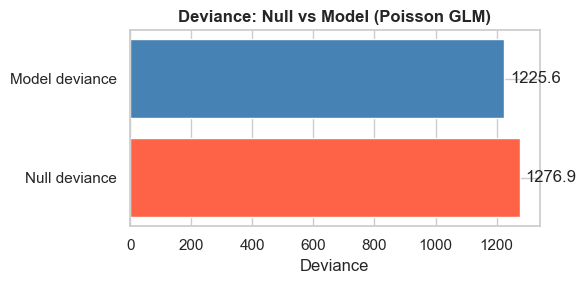

In [25]:
# Poisson GLM evaluation: pseudo-R2, deviance, Pearson chi2, MAE, RMSE

# Null model (intercept only) for pseudo-R2
X_null_tr = sm.add_constant(np.ones(len(X_train)))
X_null_te = sm.add_constant(np.ones(len(X_test)))
null_glm = sm.GLM(
    y_train, X_null_tr,
    family=sm.families.Poisson()
).fit(disp=False)

# Deviances
dev_model = poisson_glm.deviance
dev_null  = null_glm.deviance

# McFadden pseudo-R2 = 1 - (log-likelihood_model / log-likelihood_null)
llf_model = poisson_glm.llf
llf_null  = null_glm.llf
pseudo_r2_mcfadden = 1 - (llf_model / llf_null)

# Cox-Snell / Nagelkerke pseudo-R2 variants
n = len(y_train)
pseudo_r2_cs = 1 - np.exp((2/n) * (llf_null - llf_model))
pseudo_r2_nag = pseudo_r2_cs / (1 - np.exp((2/n) * llf_null))

# Test-set metrics
from sklearn.metrics import mean_absolute_error
mae  = mean_absolute_error(y_test, y_pred_glm)
rmse = mean_squared_error(y_test, y_pred_glm)

# Pearson chi2 and dispersion (on training fit)
pearson_chi2 = poisson_glm.pearson_chi2
df_resid     = poisson_glm.df_resid
dispersion   = pearson_chi2 / df_resid

# AIC / BIC
aic = poisson_glm.aic
bic = poisson_glm.bic

metrics = pd.DataFrame({
    'Metric': [
        'Pseudo-R2 (McFadden)',
        'Pseudo-R2 (Cox-Snell)',
        'Pseudo-R2 (Nagelkerke)',
        'Model Deviance (train)',
        'Null Deviance (train)',
        'Deviance Ratio (1 - dev/null_dev)',
        'Pearson chi2 / df (dispersion)',
        'AIC',
        'BIC',
        'RMSE (test)',
        'MAE  (test)',
    ],
    'Value': [
        round(pseudo_r2_mcfadden, 4),
        round(pseudo_r2_cs, 4),
        round(pseudo_r2_nag, 4),
        round(dev_model, 4),
        round(dev_null, 4),
        round(1 - dev_model / dev_null, 4),
        round(dispersion, 4),
        round(aic, 2),
        round(bic, 2),
        round(rmse, 4),
        round(mae, 4),
    ]
}).set_index('Metric')

display(metrics)

# Deviance breakdown plot
fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.barh(['Null deviance', 'Model deviance'], [dev_null, dev_model],
               color=['tomato', 'steelblue'])
ax.bar_label(bars, fmt='%.1f', padding=4)
ax.set_title('Deviance: Null vs Model (Poisson GLM)', fontweight='bold')
ax.set_xlabel('Deviance')
plt.tight_layout(); plt.show()

In [26]:
# Rebuild test-set index to align with original df_enc rows
pred_df = X_test.copy()
pred_df['actual_claim_count']    = y_test.values
pred_df['predicted_claim_count'] = y_pred_glm.values
pred_df['residual']              = pred_df['actual_claim_count'] - pred_df['predicted_claim_count']

# Attach readable coverage_type and region back (from one-hot)
cov_cols    = [c for c in pred_df.columns if c.startswith("coverage_type_")]
region_cols = [c for c in pred_df.columns if c.startswith("region_")]

pred_df = pred_df[['actual_claim_count', 'predicted_claim_count', 'residual',
                    *cov_cols, *region_cols,
                    'claim_year', 'claim_month', 'claim_quarter']]

pred_df = pred_df.reset_index(drop=True)

print(f'Shape: {pred_df.shape}')
display(pred_df.head(20))


KeyError: "['claim_month', 'claim_quarter'] not in index"

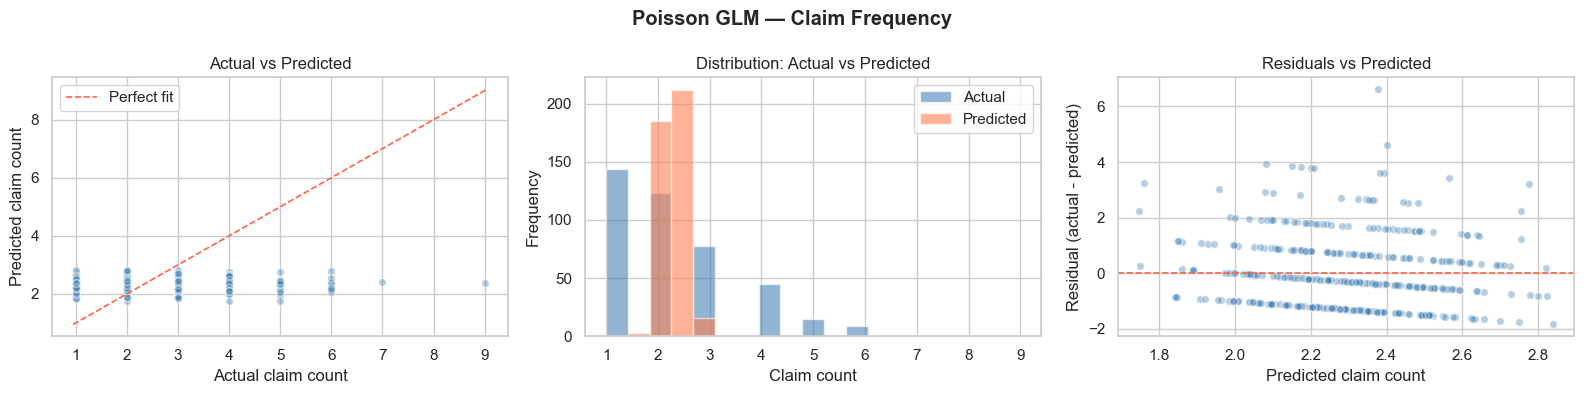

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Scatter: actual vs predicted
axes[0].scatter(pred_df["actual_claim_count"], pred_df["predicted_claim_count"],
                alpha=0.4, color="steelblue", edgecolors="white", s=30)
lims = [pred_df[["actual_claim_count","predicted_claim_count"]].min().min() - 0.05,
        pred_df[["actual_claim_count","predicted_claim_count"]].max().max() + 0.05]
axes[0].plot(lims, lims, "--", color="tomato", linewidth=1.2, label="Perfect fit")
axes[0].set_xlabel("Actual claim count")
axes[0].set_ylabel("Predicted claim count")
axes[0].set_title("Actual vs Predicted")
axes[0].legend()

# 2. Distribution comparison
bins = np.linspace(pred_df["actual_claim_count"].min(),
                   pred_df["actual_claim_count"].max(), 20)
axes[1].hist(pred_df["actual_claim_count"],    bins=bins, alpha=0.6,
             color="steelblue", label="Actual",    edgecolor="white")
axes[1].hist(pred_df["predicted_claim_count"], bins=bins, alpha=0.6,
             color="coral",     label="Predicted", edgecolor="white")
axes[1].set_xlabel("Claim count")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution: Actual vs Predicted")
axes[1].legend()

# 3. Residuals
axes[2].scatter(pred_df["predicted_claim_count"], pred_df["residual"],
                alpha=0.4, color="steelblue", edgecolors="white", s=30)
axes[2].axhline(0, color="tomato", linestyle="--", linewidth=1.2)
axes[2].set_xlabel("Predicted claim count")
axes[2].set_ylabel("Residual (actual - predicted)")
axes[2].set_title("Residuals vs Predicted")

plt.suptitle("Poisson GLM — Claim Frequency", fontweight="bold")
plt.tight_layout()
plt.show()
